<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/languages/python/mini_projects/experiment_openweathermap_weather_forecasting_dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Weather Forecasting App with OpenWeatherMap API

This notebook demonstrates how to build a simple weather forecasting app using the OpenWeatherMap API and display real-time weather data.

### 1. API Key Setup

To use the OpenWeatherMap API, you need an API key. Please obtain one from their website (e.g., [OpenWeatherMap](https://openweathermap.org/api)) and store it in Colab's secrets manager under the name `OPENWEATHER_API_KEY`. This ensures your key is not directly exposed in the notebook.

In [12]:
# Import necessary libraries
from google.colab import userdata
import requests

# Retrieve the API key from Colab secrets
OPENWEATHER_API_KEY = userdata.get('OPENWEATHER_API_KEY')

if not OPENWEATHER_API_KEY:
    raise ValueError("OPENWEATHER_API_KEY not found in Colab secrets. Please add it.")

print("API Key loaded successfully.")

API Key loaded successfully.


### 2. Fetching Current Weather Data

We'll define a function to call the OpenWeatherMap API and then use it to fetch and display current weather details for a chosen city.

In [13]:
BASE_URL = "http://api.openweathermap.org/data/2.5/weather"

def get_current_weather(city_name, api_key):
    """Fetches current weather data for a given city."""
    params = {
        'q': city_name,
        'appid': api_key,
        'units': 'metric' # You can change this to 'imperial' for Fahrenheit
    }
    try:
        response = requests.get(BASE_URL, params=params)
        response.raise_for_status() # Raise an exception for HTTP errors
        return response.json()
    except requests.exceptions.HTTPError as e:
        print(f"HTTP Error: {e.response.status_code} - {e.response.text}")
        return None
    except requests.exceptions.RequestException as e:
        print(f"Request Error: {e}")
        return None


In [14]:
# @title Enter a City Name and run the cell to get current weather
city = "Jatani" # @param {type:"string"}

print(f"Fetching weather for: {city}")
weather_data = get_current_weather(city, OPENWEATHER_API_KEY)

if weather_data:
    # Extract key information
    main_weather = weather_data['weather'][0]['main']
    description = weather_data['weather'][0]['description']
    temp = weather_data['main']['temp']
    feels_like = weather_data['main']['feels_like']
    humidity = weather_data['main']['humidity']
    wind_speed = weather_data['wind']['speed']
    pressure = weather_data['main']['pressure']

    print(f"\n--- Current Weather in {city} ---")
    print(f"Condition: {main_weather} ({description})")
    print(f"Temperature: {temp}°C (Feels like: {feels_like}°C)")
    print(f"Humidity: {humidity}%")
    print(f"Wind Speed: {wind_speed} m/s")
    print(f"Pressure: {pressure} hPa")
else:
    print(f"Could not retrieve weather data for {city}. Please check the city name and your API key.")

Fetching weather for: Jatani

--- Current Weather in Jatani ---
Condition: Clouds (overcast clouds)
Temperature: 32.67°C (Feels like: 39.67°C)
Humidity: 79%
Wind Speed: 0.45 m/s
Pressure: 1002 hPa


### 3. Fetching Weather Forecast Data

To get a more in-depth analysis, we'll use the OpenWeatherMap 5-day / 3-hour forecast API. This will allow us to see how weather parameters are expected to change over time.

In [15]:
FORECAST_URL = "http://api.openweathermap.org/data/2.5/forecast"

def get_weather_forecast(city_name, api_key):
    """Fetches 5-day / 3-hour weather forecast data for a given city."""
    params = {
        'q': city_name,
        'appid': api_key,
        'units': 'metric' # Or 'imperial' for Fahrenheit
    }
    try:
        response = requests.get(FORECAST_URL, params=params)
        response.raise_for_status() # Raise an exception for HTTP errors
        return response.json()
    except requests.exceptions.HTTPError as e:
        print(f"HTTP Error: {e.response.status_code} - {e.response.text}")
        return None
    except requests.exceptions.RequestException as e:
        print(f"Request Error: {e}")
        return None


In [18]:
# @title Get 5-day / 3-hour forecast for a city
forecast_city = "Jatani" # @param {type:"string"}

print(f"Fetching 5-day / 3-hour forecast for: {forecast_city}")
forecast_data = get_weather_forecast(forecast_city, OPENWEATHER_API_KEY)

if forecast_data and 'list' in forecast_data:
    print(f"\n--- 5-Day / 3-Hour Forecast for {forecast_city} ---")
    for entry in forecast_data['list'][:10]: # Displaying first 10 entries for brevity
        dt_txt = entry['dt_txt']
        temp = entry['main']['temp']
        description = entry['weather'][0]['description']
        print(f"Time: {dt_txt}, Temp: {temp}°C, Condition: {description}")
    print(f"\nTotal forecast entries: {len(forecast_data['list'])}")
else:
    print(f"Could not retrieve forecast data for {forecast_city}. Please check the city name and your API key.")

Fetching 5-day / 3-hour forecast for: Jatani

--- 5-Day / 3-Hour Forecast for Jatani ---
Time: 2026-07-10 09:00:00, Temp: 32.87°C, Condition: light rain
Time: 2026-07-10 12:00:00, Temp: 31.7°C, Condition: light rain
Time: 2026-07-10 15:00:00, Temp: 28.68°C, Condition: moderate rain
Time: 2026-07-10 18:00:00, Temp: 27.43°C, Condition: light rain
Time: 2026-07-10 21:00:00, Temp: 27.82°C, Condition: light rain
Time: 2026-07-11 00:00:00, Temp: 27.55°C, Condition: light rain
Time: 2026-07-11 03:00:00, Temp: 27.56°C, Condition: light rain
Time: 2026-07-11 06:00:00, Temp: 28.34°C, Condition: light rain
Time: 2026-07-11 09:00:00, Temp: 28.39°C, Condition: overcast clouds
Time: 2026-07-11 12:00:00, Temp: 27.41°C, Condition: overcast clouds

Total forecast entries: 40


### 4. Data Processing and Visualization

To perform proper analysis, we'll convert the raw JSON forecast data into a Pandas DataFrame and then visualize key weather metrics (temperature, humidity, wind speed) over time. This allows us to easily observe trends and patterns.


--- Processed Forecast Data for Jatani ---
                 Time  Temperature (°C)  Feels Like (°C)  Humidity (%)  \
0 2026-07-10 09:00:00             32.87            39.87            72   
1 2026-07-10 12:00:00             31.70            38.70            72   
2 2026-07-10 15:00:00             28.68            34.26            82   
3 2026-07-10 18:00:00             27.43            30.96            82   
4 2026-07-10 21:00:00             27.82            32.09            83   

   Wind Speed (m/s)  Pressure (hPa) Weather Condition Weather Description  \
0              4.62            1002              Rain          light rain   
1              5.28            1002              Rain          light rain   
2              1.74            1003              Rain       moderate rain   
3              4.26            1002              Rain          light rain   
4              2.56            1001              Rain          light rain   

   Probability of Precipitation (%)  
0         

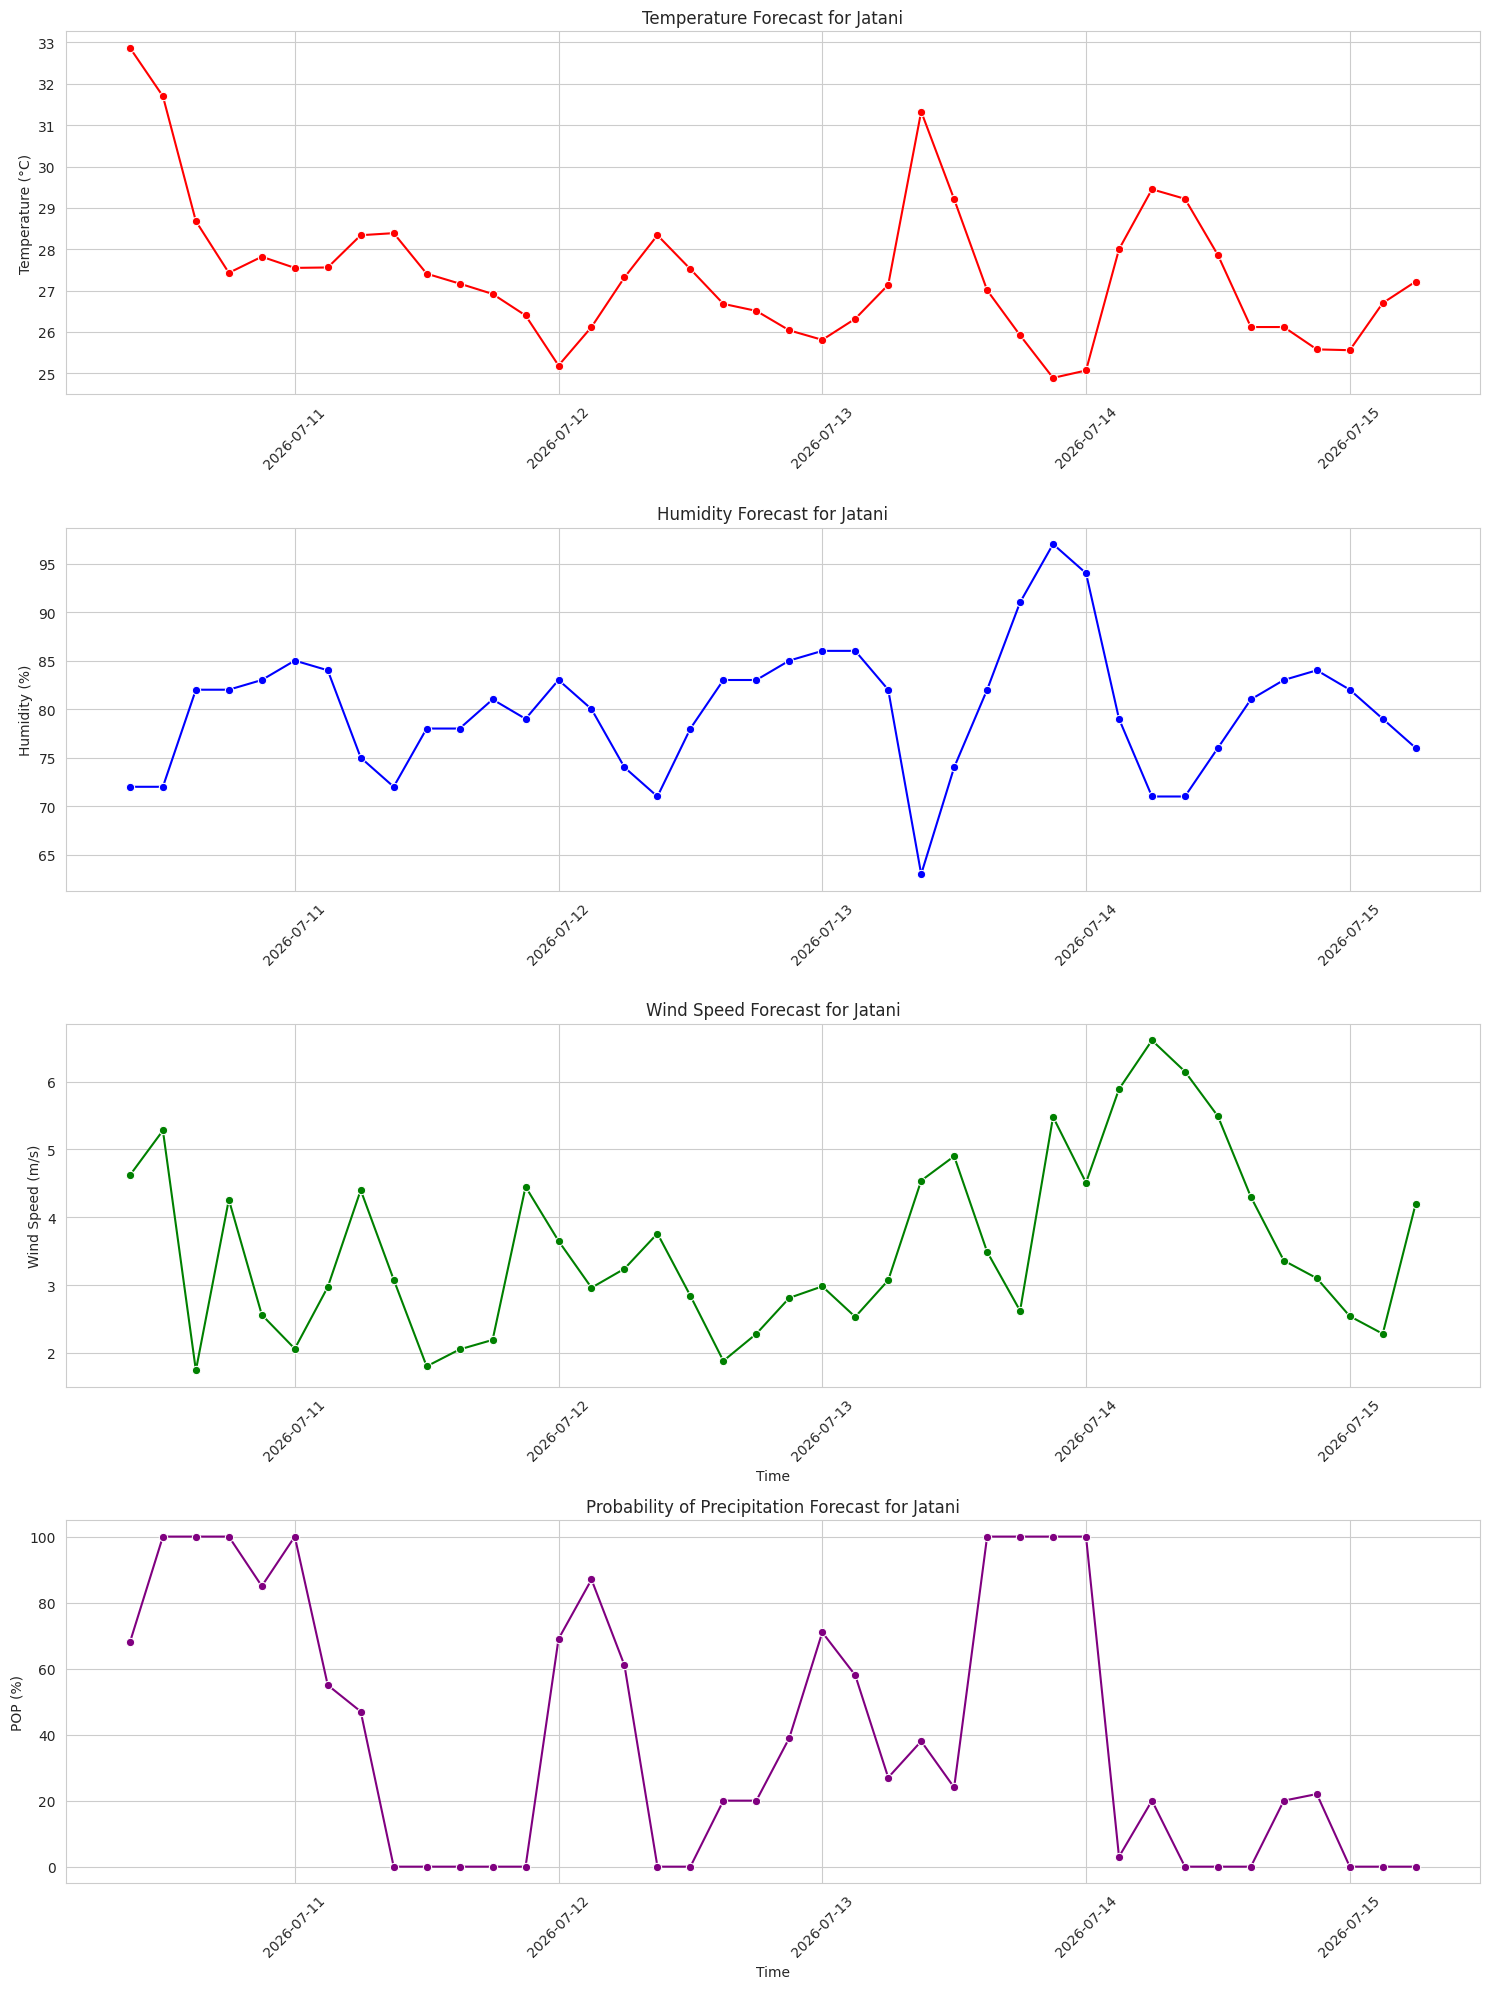


--- Summary Statistics for Jatani Forecast ---
       Temperature (°C)  Humidity (%)  Wind Speed (m/s)
count         40.000000     40.000000         40.000000
mean          27.412250     79.925000          3.573000
std            1.747827      6.592099          1.295292
min           24.890000     63.000000          1.740000
25%           26.120000     75.750000          2.555000
50%           27.195000     81.000000          3.170000
75%           28.085000     83.000000          4.465000
max           32.870000     97.000000          6.610000

--- Summary Statistics for Probability of Precipitation ---
count     40.000000
mean      40.850000
std       39.598336
min        0.000000
25%        0.000000
50%       25.500000
75%       74.500000
max      100.000000
Name: Probability of Precipitation (%), dtype: float64


In [21]:
# Import pandas and matplotlib for data processing and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure plots are displayed inline in the notebook
%matplotlib inline

def process_and_plot_forecast(forecast_data, city_name):
    """Processes forecast data into a DataFrame and plots key metrics."""
    if not forecast_data or 'list' not in forecast_data:
        print("No forecast data to process or invalid format.")
        return

    # Prepare data for DataFrame
    data = []
    for entry in forecast_data['list']:
        dt_object = pd.to_datetime(entry['dt_txt'])
        data.append({
            'Time': dt_object,
            'Temperature (°C)': entry['main']['temp'],
            'Feels Like (°C)': entry['main']['feels_like'],
            'Humidity (%)': entry['main']['humidity'],
            'Wind Speed (m/s)': entry['wind']['speed'],
            'Pressure (hPa)': entry['main']['pressure'],
            'Weather Condition': entry['weather'][0]['main'],
            'Weather Description': entry['weather'][0]['description']
        })

    df = pd.DataFrame(data)

    # Add Probability of Precipitation (POP) to the DataFrame if available
    if 'pop' in forecast_data['list'][0]:
        pop_data = [entry.get('pop', 0) * 100 for entry in forecast_data['list']]
        df['Probability of Precipitation (%)'] = pop_data
    else:
        print("Probability of Precipitation data not available in the forecast.")
        # If POP is not available, we won't try to plot it, but proceed with other plots

    print(f"\n--- Processed Forecast Data for {city_name} ---")
    print(df.head())

    # Plotting
    # Determine the number of plots dynamically based on POP data availability
    num_plots = 4 if 'Probability of Precipitation (%)' in df.columns else 3
    plt.figure(figsize=(15, 5 * num_plots))
    sns.set_style("whitegrid")

    # Temperature Plot
    plt.subplot(num_plots, 1, 1)
    sns.lineplot(x='Time', y='Temperature (°C)', data=df, marker='o', color='red')
    plt.title(f'Temperature Forecast for {city_name}')
    plt.ylabel('Temperature (°C)')
    plt.xlabel('')
    plt.xticks(rotation=45)
    plt.grid(True)

    # Humidity Plot
    plt.subplot(num_plots, 1, 2)
    sns.lineplot(x='Time', y='Humidity (%)', data=df, marker='o', color='blue')
    plt.title(f'Humidity Forecast for {city_name}')
    plt.ylabel('Humidity (%)')
    plt.xlabel('')
    plt.xticks(rotation=45)
    plt.grid(True)

    # Wind Speed Plot
    plt.subplot(num_plots, 1, 3)
    sns.lineplot(x='Time', y='Wind Speed (m/s)', data=df, marker='o', color='green')
    plt.title(f'Wind Speed Forecast for {city_name}')
    plt.ylabel('Wind Speed (m/s)')
    plt.xlabel('Time')
    plt.xticks(rotation=45)
    plt.grid(True)

    # Probability of Precipitation Plot (if available)
    if 'Probability of Precipitation (%)' in df.columns:
        plt.subplot(num_plots, 1, 4)
        sns.lineplot(x='Time', y='Probability of Precipitation (%)', data=df, marker='o', color='purple')
        plt.title(f'Probability of Precipitation Forecast for {city_name}')
        plt.ylabel('POP (%)')
        plt.xlabel('Time')
        plt.xticks(rotation=45)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Basic summary statistics
    print(f"\n--- Summary Statistics for {city_name} Forecast ---")
    print(df[['Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)']].describe())
    if 'Probability of Precipitation (%)' in df.columns:
        print(f"\n--- Summary Statistics for Probability of Precipitation ---")
        print(df['Probability of Precipitation (%)'].describe())


# Run the processing and plotting if forecast_data was successfully retrieved
if 'forecast_data' in locals() and forecast_data:
    process_and_plot_forecast(forecast_data, forecast_city)
else:
    print("Forecast data not available. Please ensure the previous cell was run successfully and the API key is valid.")

### 5. Advanced Visualization: Probability of Precipitation

To enhance our weather dashboard, let's visualize the Probability of Precipitation (POP) over the forecast period. This is a crucial metric for forecasting rain or other forms of precipitation.

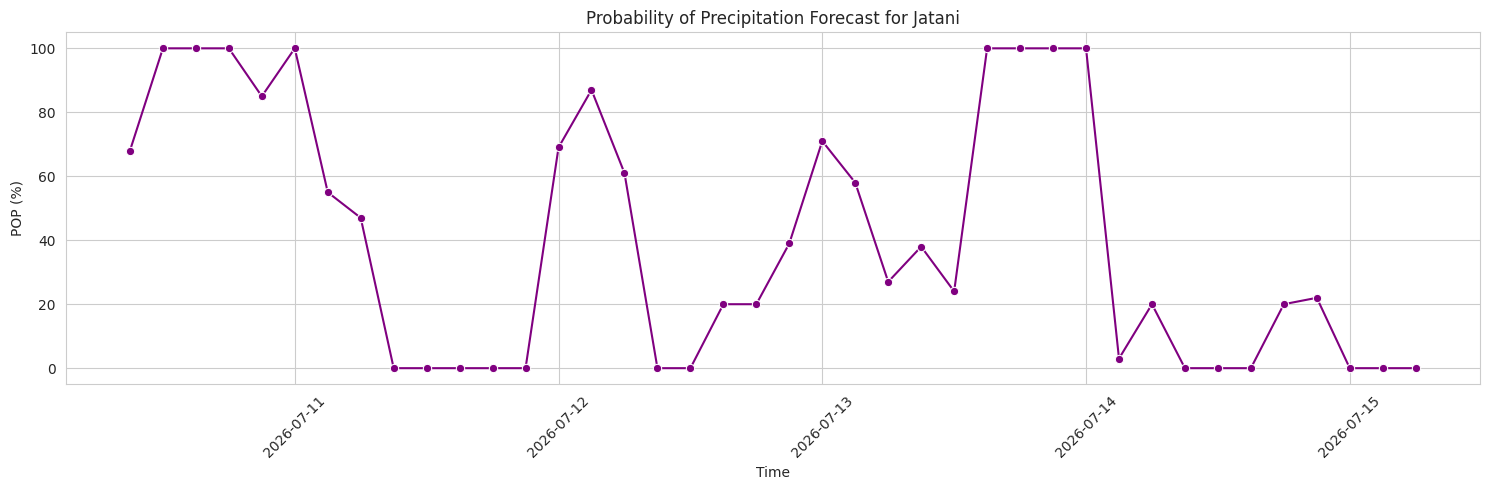


--- Summary Statistics for Probability of Precipitation ---
count     40.000000
mean      40.850000
std       39.598336
min        0.000000
25%        0.000000
50%       25.500000
75%       74.500000
max      100.000000
Name: Probability of Precipitation (%), dtype: float64


In [22]:
# Import necessary libraries for this cell
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'forecast_data' is available from previous cells.
# If this cell is run independently, you might need to run the forecast fetching cells first.

# Re-create the DataFrame 'df' for this specific plot
data = []
if 'list' in forecast_data: # Check if forecast_data has the 'list' key
    for entry in forecast_data['list']:
        dt_object = pd.to_datetime(entry['dt_txt'])
        data.append({
            'Time': dt_object,
            'Temperature (°C)': entry['main']['temp'],
            'Feels Like (°C)': entry['main']['feels_like'],
            'Humidity (%)': entry['main']['humidity'],
            'Wind Speed (m/s)': entry['wind']['speed'],
            'Pressure (hPa)': entry['main']['pressure'],
            'Weather Condition': entry['weather'][0]['main'],
            'Weather Description': entry['weather'][0]['description']
        })
df = pd.DataFrame(data)

# Add Probability of Precipitation (POP) to the DataFrame if available
if 'pop' in forecast_data['list'][0]:
    pop_data = [entry.get('pop', 0) * 100 for entry in forecast_data['list']]
    df['Probability of Precipitation (%)'] = pop_data

    plt.figure(figsize=(15, 5))
    sns.lineplot(x='Time', y='Probability of Precipitation (%)', data=df, marker='o', color='purple')
    plt.title(f'Probability of Precipitation Forecast for {forecast_city}')
    plt.ylabel('POP (%)')
    plt.xlabel('Time')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"\n--- Summary Statistics for Probability of Precipitation ---")
    print(df['Probability of Precipitation (%)'].describe())
else:
    print("Probability of Precipitation data not available in the forecast.")